In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import Axes3D
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Añadir ruta local si es necesario (ajustar según tu estructura)
sys.path.append(r'c:/Users/sebas/MalariaProject/')

#sys.path.append('/home/sgaviria/MalariaProject/')

from src import *

# Configuración de estilo para plots
#plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['font.size'] = 11

print("✅ Módulos importados correctamente")

✅ Módulos importados correctamente


In [ ]:
# ===============================================
# Reproducción de gráfica tipo paper con módulos v2
# (sin usar PaperKMCParams, LysozymeLattice ni PaperKMC_Engine)
# ===============================================

import sys
import numpy as np
import matplotlib.pyplot as plt

# Comentario: aseguramos que la raíz del proyecto esté en el path para importar src/*_v2.py
PROJECT_ROOT = r"c:/Users/sebas/MalariaProject/src"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.params_v2 import KMCParams_v2
from src.lattice_v2 import LatticeSOS_v2
from src.bkl_v2 import KMC_BKL_v2


# Comentario: datos experimentales aproximados leídos de la figura objetivo.
FACE_DATA = {
    "110": {
        "delta": 0.63,
        "E_pb_over_kT": 0.48,
        "phi_over_kT": 3.76,
        "exp_sigma": np.array([1.0, 4.0, 4.0, 6.0, 6.0, 6.0, 8.0], dtype=float),
        "exp_rate": np.array([0.00, 0.10, 0.17, 0.21, 0.28, 0.35, 0.42], dtype=float),
        "title": "(a) Cara 110",
        "marker": "+",
    },
    "101": {
        "delta": 0.30,
        "E_pb_over_kT": 2.12,
        "phi_over_kT": 4.27,
        "exp_sigma": np.array([1.0, 2.0, 4.0, 4.0, 6.0, 6.0, 6.0, 8.0], dtype=float),
        "exp_rate": np.array([0.00, 0.00, 0.09, 0.10, 0.17, 0.21, 0.28, 0.42], dtype=float),
        "title": "(b) Cara 101",
        "marker": "*",
    },
}

# Comentario: malla de sobresaturación para la curva propuesta.
SIGMA_GRID = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], dtype=float)

# Comentario: configuración de simulación (ajustable si quieres más precisión o más velocidad).
RUN_CFG = {
    "lattice_size": 24,
    "num_trials": 3,
    "total_kmc_time": 35.0,
    "time_scale": 55.0,
    "max_events": 350_000,
    "K0_plus": 0.211,
    "C_eq": 15.0,
    "seed_base": 1200,
}


def _mean_height(lattice: LatticeSOS_v2) -> float:
    """Devuelve la altura media de toda la superficie."""
    return float(np.mean(lattice.heights))


def _build_v2_params(sigma: float, face_cfg: dict) -> KMCParams_v2:
    """Construye parámetros físicos v2 para una cara y sigma dados."""
    return KMCParams_v2(
        K0_plus=float(RUN_CFG["K0_plus"]),
        E_pb_over_kT=float(face_cfg["E_pb_over_kT"]),
        phi_over_kT=float(face_cfg["phi_over_kT"]),
        delta=float(face_cfg["delta"]),
        V=1.0,
        C_eq=float(RUN_CFG["C_eq"]),
        fixed_sigma=float(sigma),
        S_floor=-5.0,
        S_ceil=8.0,
    )


def _seed_surface(lattice: LatticeSOS_v2, rng: np.random.Generator, n_seeds: int) -> None:
    """Siembra pequeñas islas iniciales para evitar estado trivial totalmente plano."""
    nx, ny = lattice.heights.shape
    for _ in range(int(n_seeds)):
        i = int(rng.integers(0, nx))
        j = int(rng.integers(0, ny))
        lattice.inc_height((i, j), 1)


def _simulate_growth_rate_face_sigma(face_cfg: dict, sigma: float, trial_idx: int) -> float:
    """Ejecuta un trial kMC y devuelve tasa de crecimiento media (altura/tiempo)."""
    seed_offset = int(RUN_CFG["seed_base"]) + 100 * trial_idx

    # Comentario: red SOS v2 sin restricciones geométricas específicas.
    lattice = LatticeSOS_v2(size=(RUN_CFG["lattice_size"], RUN_CFG["lattice_size"]), seed=seed_offset)
    lattice.initialize(mode="flat")

    # Comentario: se agrega rugosidad inicial leve para disparar escalones/kinks.
    rng_local = np.random.default_rng(seed_offset + 17)
    _seed_surface(lattice, rng_local, n_seeds=max(6, RUN_CFG["lattice_size"] // 3))

    params = _build_v2_params(sigma=sigma, face_cfg=face_cfg)

    # Comentario: N_bulk0 es irrelevante en práctica cuando fixed_sigma está definido,
    # pero se deja en valor alto para mantener consistencia física del reservorio.
    engine = KMC_BKL_v2(
        lattice=lattice,
        params=params,
        N_bulk0=int(1e6),
        rng_seed=seed_offset + 43,
        time_scale=float(RUN_CFG["time_scale"]),
        n_seeds=0,
        debug=False,
        constant_concentration=True,
    )

    h0 = _mean_height(lattice)
    t0 = float(engine.t)

    # Comentario: corrida principal hasta tiempo objetivo con tope de seguridad de eventos.
    engine.run(
        t_end=float(RUN_CFG["total_kmc_time"]),
        max_events=int(RUN_CFG["max_events"]),
    )

    h1 = _mean_height(lattice)
    dt = float(engine.t - t0)

    if dt <= 0.0:
        return 0.0
    return max(0.0, float((h1 - h0) / dt))


def _compute_proposed_curve(face_key: str, face_cfg: dict):
    """Calcula curva propuesta (v2) promediando múltiples trials por sigma."""
    sigma_vals = SIGMA_GRID.copy()
    mean_rates = []

    print(f"\n--- Cara {face_key}: simulación con módulos v2 ---")
    for sigma in sigma_vals:
        trial_rates = []
        for trial in range(int(RUN_CFG["num_trials"])):
            rate = _simulate_growth_rate_face_sigma(face_cfg=face_cfg, sigma=float(sigma), trial_idx=trial)
            trial_rates.append(rate)

        avg_rate = float(np.mean(np.array(trial_rates, dtype=float))) if len(trial_rates) > 0 else 0.0
        mean_rates.append(avg_rate)
        print(f"sigma={sigma:.1f} | growth_rate={avg_rate:.5f} (u.a.)")

    mean_rates = np.array(mean_rates, dtype=float)

    # Comentario: imponemos tendencia no decreciente para eliminar ruido estocástico de pocos trials.
    mean_rates = np.maximum.accumulate(mean_rates)

    # Comentario: escalar amplitud para comparabilidad visual con el eje experimental (um/min).
    exp_max = float(np.max(face_cfg["exp_rate"]))
    sim_max = float(np.max(mean_rates))
    scale = exp_max / sim_max if sim_max > 0.0 else 1.0
    proposed = mean_rates * scale

    return sigma_vals, proposed


def _previous_model_curve(sigma_vals: np.ndarray, face_key: str) -> np.ndarray:
    """Curva del modelo previo: crecimiento muy bajo, casi plano, como en la figura."""
    sigma_vals = np.array(sigma_vals, dtype=float)
    if face_key == "110":
        # Comentario: curva casi nula con leve incremento en alta sobresaturación.
        return 0.0007 + 0.00035 * (sigma_vals - 1.0) ** 2
    # Comentario: en 101 se observa un incremento algo mayor en la línea punteada.
    return 0.0009 + 0.00045 * (sigma_vals - 1.0) ** 2


def _decorate_phase_regions(ax):
    """Dibuja regiones Spiral / Step / Rough con sombreado de fondo."""
    ax.axvspan(0.0, 3.0, color="#efe3b4", alpha=0.85, zorder=0)
    ax.axvspan(3.0, 6.0, color="#dfc29f", alpha=0.85, zorder=0)
    ax.axvspan(6.0, 9.0, color="#c8d6bc", alpha=0.85, zorder=0)

    ax.text(1.5, 0.24, "Spiral", ha="center", va="center", fontsize=17)
    ax.text(4.5, 0.24, "Step", ha="center", va="center", fontsize=17)
    ax.text(7.5, 0.24, "Rough", ha="center", va="center", fontsize=17)


def plot_growth_figure_v2(face_results: dict):
    """Grafica final estilo paper con dos subplots verticales."""
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 12,
    })

    fig, axes = plt.subplots(2, 1, figsize=(6.2, 10.2), sharex=False)

    for ax, face_key in zip(axes, ["110", "101"]):
        cfg = FACE_DATA[face_key]
        sigma_vals, proposed_vals, previous_vals = face_results[face_key]

        _decorate_phase_regions(ax)

        # Comentario: puntos experimentales.
        # ax.scatter(
        #     cfg["exp_sigma"],
        #     cfg["exp_rate"],
        #     color="royalblue",
        #     marker=cfg["marker"],
        #     s=70,
        #     linewidths=1.0,
        #     label="Experimental",
        #     zorder=4,
        # )

        # Comentario: interpolación lineal para mostrar una curva continua suave.
        sigma_dense = np.linspace(float(np.min(sigma_vals)), float(np.max(sigma_vals)), 300)
        proposed_dense = np.interp(sigma_dense, sigma_vals, proposed_vals)
        #previous_dense = np.interp(sigma_dense, sigma_vals, previous_vals)

        ax.plot(sigma_dense, proposed_dense, color="red", linewidth=2.0, zorder=3)
        #ax.plot(sigma_dense, previous_dense, color="black", linewidth=2.0, linestyle=":", label="Previous model", zorder=2)

        ax.set_xlim(0.0, 9.0)
        ax.set_ylim(0.0, 0.5)
        ax.set_ylabel(r"Tasa de crecimiento ($\mu m/min$)", fontsize=18)
        ax.set_title(cfg["title"], loc="left", fontsize=18)
        ax.tick_params(axis="both", labelsize=15)
        # ax.legend(
        #     loc="upper left",
        #     frameon=True,
        #     fancybox=False,
        #     framealpha=1.0,
        #     fontsize=10,
        #     borderpad=0.3,
        #     labelspacing=0.3,
        #     handlelength=1.8,
        #     handletextpad=0.4,
        # )

        # Comentario: formato de ticks para parecerse a la figura original.
        y_ticks = np.arange(0.0, 0.51, 0.1)
        y_labels = ["0" if np.isclose(v, 0.0) else f"{v:.1f}" for v in y_ticks]
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels)

    axes[0].set_xlabel(r"Sobresaturación ($\sigma$)", fontsize=20)
    axes[1].set_xlabel(r"Sobresaturación ($\sigma$)", fontsize=20)

    plt.tight_layout()
    plt.show()


# Comentario: ejecuta simulación para ambas caras y luego grafica.
face_results = {}
for face_key, cfg in FACE_DATA.items():
    sigma_vals, proposed_vals = _compute_proposed_curve(face_key=face_key, face_cfg=cfg)
    previous_vals = _previous_model_curve(sigma_vals=sigma_vals, face_key=face_key)
    face_results[face_key] = (sigma_vals, proposed_vals, previous_vals)

plot_growth_figure_v2(face_results)


--- Cara 110: simulación con módulos v2 ---
sigma=1.0 | growth_rate=0.00211 (u.a.)
sigma=2.0 | growth_rate=0.00333 (u.a.)
sigma=3.0 | growth_rate=0.00457 (u.a.)
sigma=4.0 | growth_rate=0.00617 (u.a.)
sigma=5.0 | growth_rate=0.00777 (u.a.)
sigma=6.0 | growth_rate=0.01033 (u.a.)
sigma=7.0 | growth_rate=0.01250 (u.a.)


In [3]:
archivo = "beta-hematina.txt"

data_txt = pd.read_csv(archivo, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

#times = np.linspace(0, 300, 20)
times_txt = np.array(data_txt['Tiempo'])
all_times = np.array(list(set(times_txt/5) | set(times_txt/4) | set(times_txt/2) | set(times_txt)))

times = times_txt

In [4]:
times = np.arange(0, 151, 1)

In [5]:
times

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150])

In [6]:
# sigmas = np.linspace(1, 8, 80)
sigmas = np.arange(1, 8.2, 0.2)

In [7]:
sigmas

array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. , 3.2, 3.4,
       3.6, 3.8, 4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. ,
       6.2, 6.4, 6.6, 6.8, 7. , 7.2, 7.4, 7.6, 7.8, 8. ])

In [8]:
def compute_probabilities(sigmas, times, delta, size=(75, 75), mode="flat", n_seeds=1):

    prob_sta = []
    kmcs = []
    snaps_list = []

    # L = LatticeSOS_v2(size=size, seed=42)
    # # L.initialize(mode="random", max_height=1, n_seeds=1905)
    # L.initialize(mode=mode)

    for sigma in sigmas:
        print(f"\n\n=== σ = {sigma} ===")

        L = LatticeSOS_v2(size=size, seed=42+int(sigma))
        # L.initialize(mode="random", max_height=1, n_seeds=1905)
        L.initialize(mode=mode, max_height=0, n_seeds=n_seeds)

        params = KMCParams_v2(
        K0_plus= 2.116718e-13, #0.211,
        E_pb_over_kT= 1.2704636027368605, #.48,
        phi_over_kT= 1.792478012079329, #3.76,
        delta=delta,
        V=1,
        C_eq=15.0,
        fixed_sigma=sigma,   # usa un valor como 3.0 si quieres sigma estático
        S_floor=-5.0,
        S_ceil=9.0,
        )

        kmc = KMC_BKL_v2(
            lattice=L,
            params=params,
            N_bulk0=1000,
            rng_seed=123,
            time_scale=2,
            n_seeds=n_seeds,
            constant_concentration=True,  # batch dinámico
        )
        kmcs.append(kmc)

        snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)
        snaps_list.append(snaps)

        prob_sta.append(stats['adsorption_probs_history'])

        print(f"Datos para σ = {sigma} guardados.\n")

    return prob_sta, kmcs, snaps_list

In [9]:
# ============================================
# Extraer p0, p1, p2 desde prob_sta
# ============================================

def extraer_probs_desde_prob_sta(prob_sta):
    # Devuelve probabilidades promedio en la cola temporal para cada sigma
    p0, p1, p2 = [], [], []
    sigmas_plot = []

    for hist in prob_sta:
        # Si no hay historial para ese sigma, guardar NaN
        if len(hist) == 0:
            p0.append(np.nan); p1.append(np.nan); p2.append(np.nan); sigmas_plot.append(np.nan)
            continue

        # Sigma asociado a esa corrida (constante en esa historia)
        sigmas_plot.append(float(hist[-1][1]))

        # Tomar la cola temporal para aproximar estado cuasi-estacionario
        #n = len(hist)
        #k0 = max(0, int((1.0 - frac_tail) * n))
        tail = hist[:]

        vals0, vals1, vals2 = [], [], []
        for _, _, probs in tail:
            vals0.append(float(probs.get(0, 0.0)))
            vals1.append(float(probs.get(1, 0.0)))
            vals2.append(float(probs.get(2, 0.0)))

        # Promedio por sigma
        p0.append(np.mean(vals0) if len(vals0) else np.nan)
        p1.append(np.mean(vals1) if len(vals1) else np.nan)
        p2.append(np.mean(vals2) if len(vals2) else np.nan)

    return np.array(sigmas_plot), np.array(p0), np.array(p1), np.array(p2)

In [10]:
def plot_probs_vs_sigma(sigmas_plot, p0, p1, p2, path=None):
    # Ordenar por sigma por seguridad (por si llegan desordenados)
    idx = np.argsort(sigmas_plot)
    sigmas_plot = sigmas_plot[idx]
    p0 = p0[idx]
    p1 = p1[idx]
    p2 = p2[idx]

    # ============================================
    # Gráfica
    # ============================================
    fig, ax = plt.subplots()
    plt.gca().set_facecolor("#e9e9e9")

    # Regiones de régimen
    # ax.axvspan(1.0, 2.5, alpha=0.1, color='gold')
    # ax.axvspan(2.5, 6.0, alpha=0.1, color='orange')
    # ax.axvspan(6.0, 8.0, alpha=0.1, color='green')

    # ax.text(1.8, 0.52, 'SPIRAL', fontsize=11, ha='center', fontweight='bold', color='darkgoldenrod')
    # ax.text(4.25, 0.52, 'STEP', fontsize=11, ha='center', fontweight='bold', color='darkorange')
    # ax.text(7.0, 0.52, 'ROUGH', fontsize=11, ha='center', fontweight='bold', color='darkgreen')

    # Curvas de probabilidad extraídas desde prob_sta
    plt.plot(sigmas_plot, p0, color="#0072BD", linewidth=2.5, label='adatom (i = 0)')
    plt.plot(sigmas_plot, p1, color="#D95319", linewidth=2.5, label='step (i = 1)')
    plt.plot(sigmas_plot, p2, color="#EDB120", linewidth=2.5, label='kink (i = 2)')

    plt.xlim(1, 8)
    plt.ylim(0, 1)
    plt.xlabel("Sobresaturación (σ)")
    plt.ylabel("Probabilidad")
    plt.title("Probabilidades por sitio de adsorción")
    plt.legend()

    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True
    )
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    plt.grid(False)
    if path:
        plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()

In [11]:
print(f"{(2820/40000)*100} %")

7.049999999999999 %


In [12]:
0.07*5625

393.75000000000006

In [13]:
75*75

5625



=== σ = 1.0 ===
Datos para σ = 1.0 guardados.



=== σ = 1.2 ===
Datos para σ = 1.2 guardados.



=== σ = 1.4 ===
Datos para σ = 1.4 guardados.



=== σ = 1.5999999999999999 ===
Datos para σ = 1.5999999999999999 guardados.



=== σ = 1.7999999999999998 ===
Datos para σ = 1.7999999999999998 guardados.



=== σ = 1.9999999999999998 ===
Datos para σ = 1.9999999999999998 guardados.



=== σ = 2.1999999999999997 ===
Datos para σ = 2.1999999999999997 guardados.



=== σ = 2.3999999999999995 ===
Datos para σ = 2.3999999999999995 guardados.



=== σ = 2.5999999999999996 ===
Datos para σ = 2.5999999999999996 guardados.



=== σ = 2.8 ===
Datos para σ = 2.8 guardados.



=== σ = 2.9999999999999996 ===
Datos para σ = 2.9999999999999996 guardados.



=== σ = 3.1999999999999993 ===
Datos para σ = 3.1999999999999993 guardados.



=== σ = 3.3999999999999995 ===
Datos para σ = 3.3999999999999995 guardados.



=== σ = 3.5999999999999996 ===
Datos para σ = 3.5999999999999996 guardados.



=== σ = 3.79

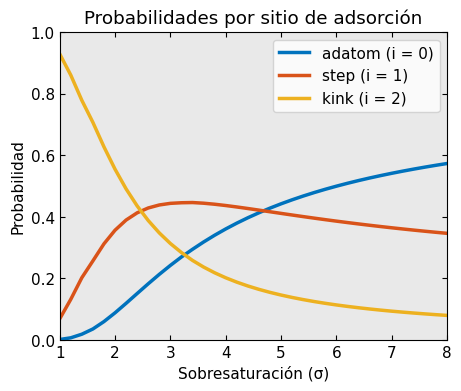

In [14]:
prob_sta, kmcs, snaps_list = compute_probabilities(sigmas, times, delta=4.18, size=(75, 75), mode="flat", n_seeds=126)
sigmas_plot, p0, p1, p2 = extraer_probs_desde_prob_sta(prob_sta)
#plot_probs_vs_sigma(sigmas_plot, p0, p1, p2, path = "probabilidades_vs_sigma_75_126_418.png")
plot_probs_vs_sigma(sigmas_plot, p0, p1, p2)

In [8]:
35*35

1225

In [12]:
kmcs

In [14]:
kmc0 = kmcs[0]
A_Bins_0 = kmc0._classify_adsorption_sites()

In [16]:
for i in range(5):
    print(f"{i}: {len(A_Bins_0[i])}")

0: 805
1: 334
2: 84
3: 2
4: 0


In [11]:
plotter = Plotter_v2(kmcs[0])

🧩 Snapshot seleccionado: t=150.000
💾 Imagen guardada en: crystal_growth.png


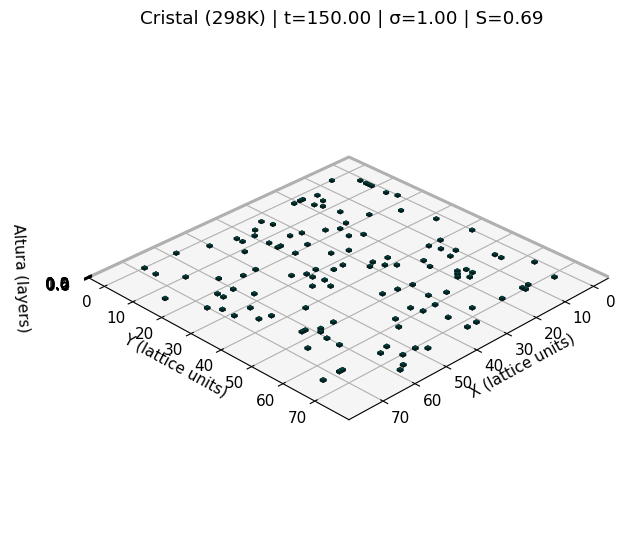

In [14]:
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_list[0],
    t_snapshot=times[len(times)- 1],
    save_path="crystal_growth.png",
)

In [16]:
plotter.crystal_growth_gif(
    snapshots=snaps_list[5],
    save_path="crystal_growth_25.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_25.gif


In [236]:
times = np.arange(0, 10, 1)

L = LatticeSOS_v2(size=(55, 55), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L.initialize(mode="flat", max_height=0)

params = KMCParams_v2(
K0_plus= 0.2116718, #0.211,
E_pb_over_kT= 2.2704636027368605, #.48,
phi_over_kT= 1.3792478012079329, #3.76,
delta=1,
V=1,
C_eq=15.0,
fixed_sigma=8,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc = KMC_BKL_v2(
    lattice=L,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=50,
    n_seeds=524,
    constant_concentration=True,  # batch dinámico
)

In [237]:
snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)

🧩 Snapshot seleccionado: t=9.000
💾 Imagen guardada en: crystal_growth_prueba.png


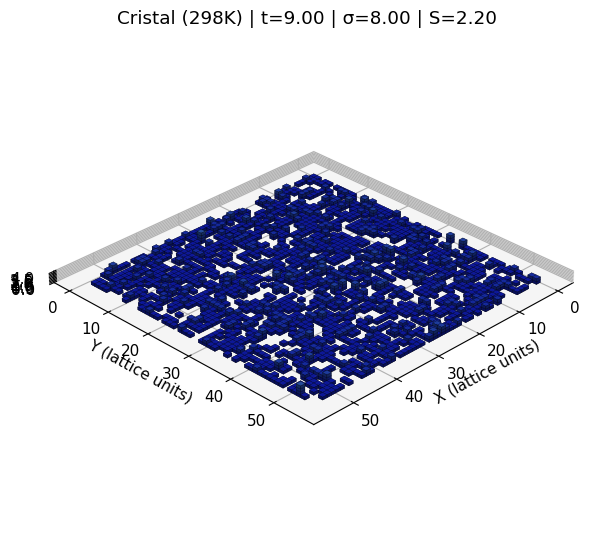

In [239]:
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_4.png",
)

In [147]:
A_bins = kmc._classify_adsorption_sites()

In [142]:
A_bins_1 = kmc._classify_adsorption_sites()

In [143]:
for i in range(3):
    print(f"{i}: {len(A_bins_1[i])}")

0: 549
1: 357
2: 227


In [148]:
for i in range(3):
    print(f"{i}: {len(A_bins[i])}")

0: 831
1: 351
2: 42


KeyboardInterrupt: 

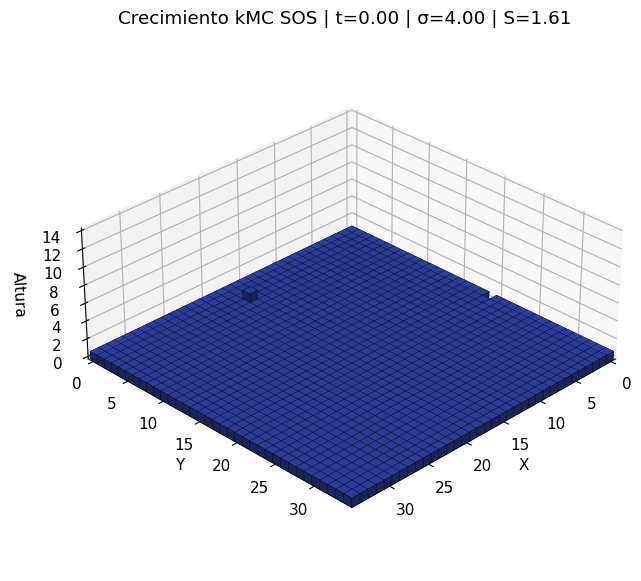

In [133]:
plotter.crystal_growth_gif(
    snapshots=snaps,
    save_path="crystal_growth_prueba_g4.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

In [20]:
35*35

1225